In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']

In [9]:
# 读取数据
df1 = pd.read_csv('/Users/Curry/Desktop/RentFromDanke/bj_danke_1.csv')
df2 = pd.read_csv('/Users/Curry/Desktop/RentFromDanke/bj_danke_2.csv')
df3 = pd.read_csv('/Users/Curry/Desktop/RentFromDanke/bj_danke_3.csv')

In [12]:
df1.head(3)

,价格,面积,编号,户型,楼层,位置1,位置2,小区,地铁
0,1330.0,9.0,38738-A,3室1卫,9/11层,房山区,良乡大学城西,紫汇家园,地铁：距房山线良乡大学城西站550米
1,5810.0,39.0,64752-A,1室1卫,9/12层,东城区,广渠门内,绿景苑,地铁：距7号线广渠门内站650米
2,4820.0,36.0,65359-A,1室1卫,1/6层,东城区,景泰,定安里,地铁：距14号线东段景泰站450米


In [13]:
# 合并数据
df = pd.concat([df1, df2, df3])

In [83]:
df.to_csv('/Users/Curry/Desktop/RentFromDanke/bj_rent.csv',index=False)

In [14]:
# 查看数据
print(df.head())

       价格     面积       编号    户型     楼层  位置1     位置2       小区  \
0  1330.0    9.0  38738-A  3室1卫  9/11层  房山区  良乡大学城西     紫汇家园   
1  5810.0   39.0  64752-A  1室1卫  9/12层  东城区    广渠门内      绿景苑   
2  4820.0   36.0  65359-A  1室1卫   1/6层  东城区      景泰      定安里   
3  1850.0    9.0    185-B  4室2卫  2/27层  朝阳区      管庄  京通苑阳光华苑   
4  9000.0  116.0  17830-A  2室1卫  8/16层  朝阳区     十里堡     天天朝阳   

                   地铁  
0  地铁：距房山线良乡大学城西站550米  
1    地铁：距7号线广渠门内站650米  
2   地铁：距14号线东段景泰站450米  
3      地铁：距八通线管庄站500米  
4     地铁：距6号线十里堡站850米  


In [21]:
#数据清洗
df['价格'] = pd.to_numeric(df['价格'],errors='coerce')
df['面积'] = pd.to_numeric(df['面积'],errors='coerce')

df = df.dropna(subset=['价格','面积'])

In [22]:
#新增特征
df['每平米价格'] = df['价格'] / df['面积']


/var/folders/w5/2rrg4h2960l1_9mhd7crl3ph0000gp/T/ipykernel_48270/3585518043.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['每平米价格'] = df['价格'] / df['面积']


In [23]:
print(df.describe())

                 价格           面积        每平米价格
count   1896.000000  1896.000000  1896.000000
mean    2705.632911    16.839135   193.019604
std     1360.207776    15.724172    66.511150
min     1110.000000     5.000000    45.172414
25%     1900.000000    10.000000   145.833333
50%     2380.000000    12.000000   187.000000
75%     2932.500000    16.000000   233.409091
max    11590.000000   120.000000   488.333333


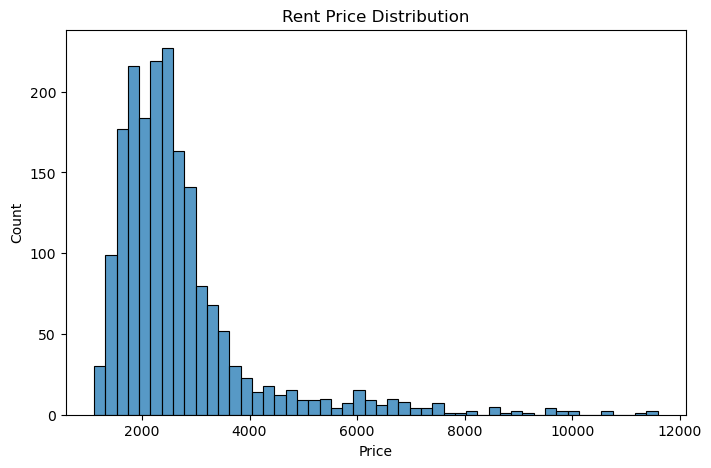

In [28]:
#1租金分布
plt.figure(figsize=(8,5))
sns.histplot(df['价格'],bins=50)
plt.title('Rent Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

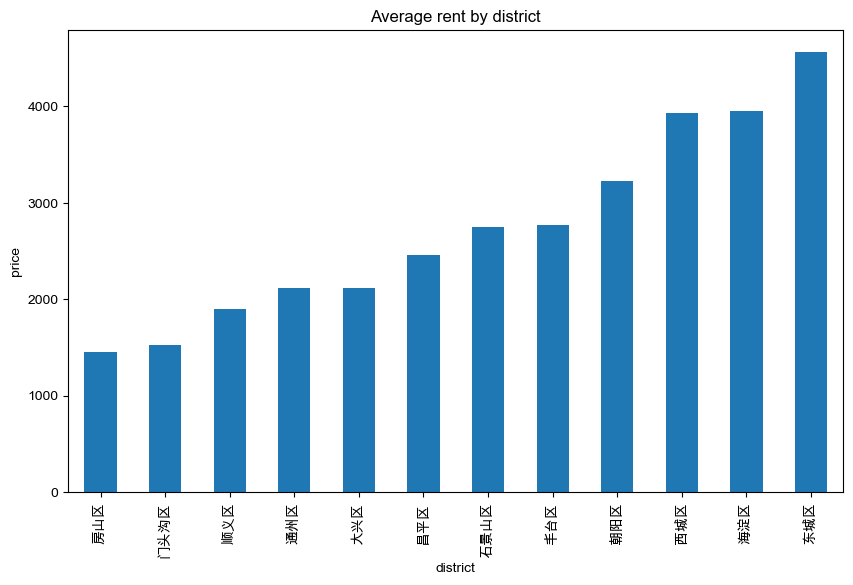

In [51]:
# 2不同区域平均租金
district_price = df.groupby('位置1')['价格'].mean().sort_values()

plt.figure(figsize=(10,6))
district_price.plot(kind='bar')
plt.title('Average rent by district')
plt.xlabel('district')
plt.ylabel('price')

plt.show()

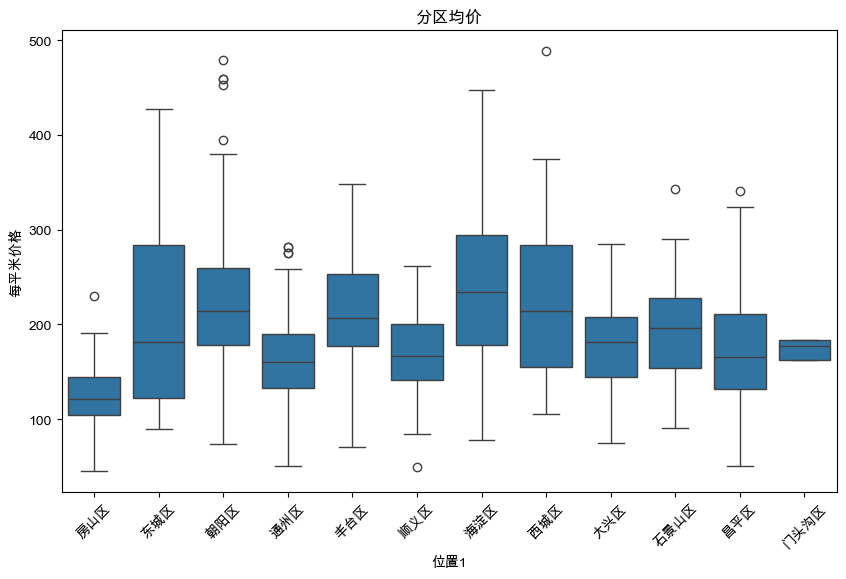

In [66]:
# 3单位面积租金
plt.figure(figsize=(10,6))
sns.boxplot(x='位置1', y='每平米价格',data=df)
plt.xticks(rotation=45)
plt.title('分区均价')
plt.show()

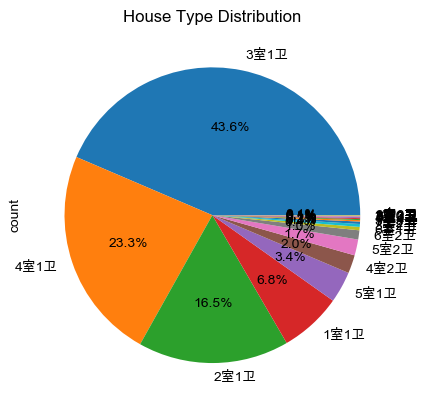

In [70]:
# 4户型分布
户型= df['户型'].value_counts()

户型.plot(kind='pie',autopct='%1.1f%%')
plt.title('House Type Distribution')
plt.show()

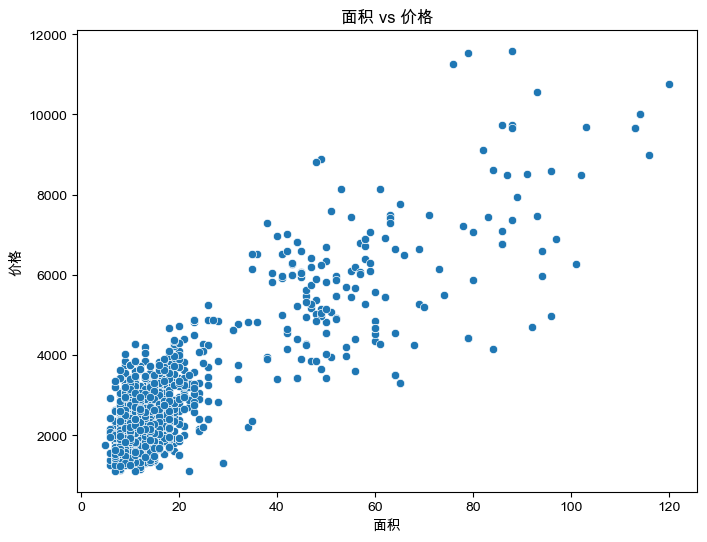

In [71]:
# 5面积 vs 租金
plt.figure(figsize=(8,6))
sns.scatterplot(x='面积', y='价格',data=df)
plt.title('面积 vs 价格')
plt.show()

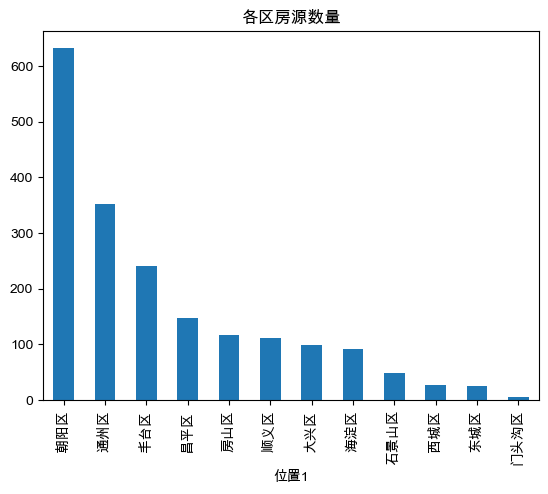

In [74]:
# 6各区房源数量
各区房源数量 = df['位置1'].value_counts()

各区房源数量.plot(kind='bar')
plt.title('各区房源数量')
plt.show()


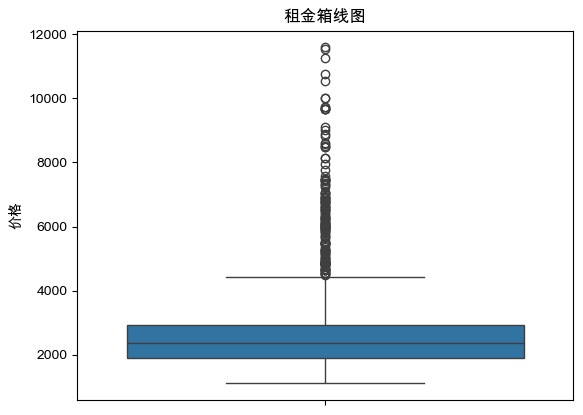

In [76]:
# 7租金箱线图
sns.boxplot(df['价格'])
plt.title('租金箱线图')
plt.show()

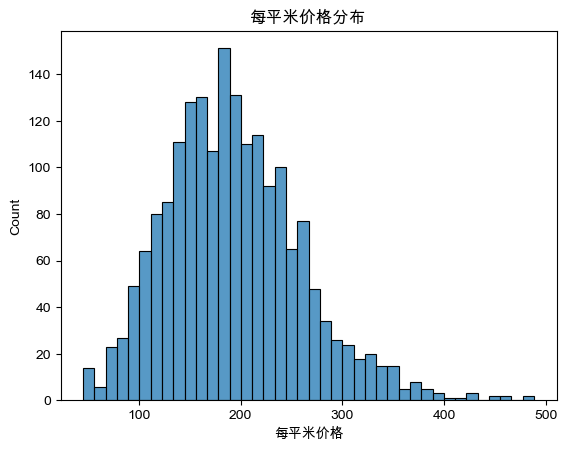

In [77]:
# 8每平米价格分布
sns.histplot(df['每平米价格'], bins=40)
plt.title('每平米价格分布')
plt.show()

In [82]:
# 机器学习预测房租（Linear Regression)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

In [85]:
# 读取数据
df = pd.read_csv('/Users/Curry/Desktop/RentFromDanke/bj_rent.csv')

In [87]:
df.head(2)

,价格,面积,编号,户型,楼层,位置1,位置2,小区,地铁,每平米价格
0,1330.0,9.0,38738-A,3室1卫,9/11层,房山区,良乡大学城西,紫汇家园,地铁：距房山线良乡大学城西站550米,147.777778
1,5810.0,39.0,64752-A,1室1卫,9/12层,东城区,广渠门内,绿景苑,地铁：距7号线广渠门内站650米,148.974359


In [88]:
# 数据清洗
df = df.dropna(subset=['价格','面积','位置1','户型'])

In [89]:
# 特征
X = df[['面积','位置1','户型']]

In [90]:
# 目标变量
y = df['价格']

In [91]:
# 类别特征编码
categorical = ['位置1','户型']
numeric = ['面积']

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', 'passthrough', numeric)
    ])

In [92]:
# 模型
model = Pipeline([
    ('preprocess',preprocess),
    ('regressor',LinearRegression())
])

In [93]:
# 训练集测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['位置1', '户型']),
                                                 ('num', 'passthrough',
                                                  ['面积'])])),
                ('regressor', LinearRegression())])

In [94]:
# 预测
pred = model.predict(X_test)

In [102]:
# 误差
rmse = mean_squared_error(y_test,pred)

print('RMSE:',rmse)

RMSE: 250438.86725286924


In [104]:
#预测租金
sample = pd.DataFrame({
    '面积':[25],
    '位置1':['海淀'],
    '户型':['1室1卫']
})

model.predict(sample)

array([3743.81866556])